# TP1 - Bonus: población heterogénea

Este notebook extiende el modelo de embarque de [`tp1_simulaciones.ipynb`](tp1_simulaciones.ipynb), sumando heterogeneidad. Agrega:

1. Personas con movilidad reducida (ancianos, personas con discapacidad, embarazadas): se mueven y
   se sientan más lento.
2. Familias / Grupos que compraron el ticket juntos: suben juntos al avión y
   rompen con las políticas WILMA / Steffen.

> **Nota: el motor de simulación 
> es una **copia** del notebook base.


## 1. Parámetros para experimentar

Estos son las variables que modfician la simulación. Cambiarlas altera los resultados.

Los factores y probabilidades son **supuestos calibrables** (ver el markdown explicativo).

In [ ]:
# PARÁMETROS PARA EXPERIMENTAR 
P_CARRYON = 0.5          # prob. de que un pasajero tenga carry-on (igual que el base)

# --- Movilidad reducida ---
P_MOV_REDUCIDA   = 0.15  # prob. de que un pasajero tenga movilidad reducida
FACTOR_CAMINAR_MR  = 1.8 # cuánto más lento camina (x veces) alguien con mov. reducida
FACTOR_SENTARSE_MR = 1.5 # cuánto más tarda en sentarse / dejar pasar


# Familias / grupos 
# Distribución del tamaño de grupo que se sortea POR FILA (aprox. de la realidad).
# 1 = pasajeros solos; 2/3/4 = familias de ese tamaño con asientos adyacentes.
DIST_TAMANOS = {1: 0.45, 2: 0.35, 3: 0.10, 4: 0.10}

# Monte Carlo 
N_CORRIDAS = 300         # subir a 1000 para resultados más finos (más lento)

## 2. Armado del avión (copia del base)

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

n_filas = 25
# -2 ventana izq | -1 pasillo izq | 1 pasillo der | 2 ventana der
lados = [-2, -1, 1, 2]

asientos = []
for fila in range(1, n_filas + 1):
    for lado in lados:
        asientos.append((fila, lado))

print(f"Cantidad de asientos: {len(asientos)}")

Cantidad de asientos: 100


## 3. Clase Pasajero con movilidad reducida

Cambios respecto del base:
- `perfil_movilidad(p_mov)` sortea si el pasajero tiene movilidad reducida (análogo a `carry_on`).
- en `__init__` se guarda `movilidad_reducida` y `grupo_id`, y se **enlentece la
  velocidad de caminata**.
- `tiempo_sentado()` y `tiempo_dejar_pasar()` tardan más si hay movilidad reducida.

El resto de la clase es idéntico al notebook base.

In [ ]:
def carry_on(p):
    return 1 if random.random() < p else 0

# BONUS 
def perfil_movilidad(p_mov):
    """Devuelve True/False: si el pasajero tiene movilidad reducida."""
    return random.random() < p_mov

# Estados posibles de un pasajero
ESTADO_CAMINANDO = 0
ESTADO_SENTADO = 1
ESTADO_BLOQUEADO = 2
ESTADO_GUARDANDO_CARRYON = 3
ESTADO_SENTANDOSE = 4

# Tipos de accion con tiempo
ACCION_CAMINAR = "caminar"
ACCION_GUARDAR_CARRYON = "guardar_carryon"
ACCION_SENTARSE = "sentarse"

COLUMNA_PASILLO = 2  # columna central de self.matriz


class Pasajero:
    """Representa a un pasajero: su asiento, su recorrido y su estado en cada segundo."""

    def __init__(self, asiento, id, p_carryon=0.5, p_mov=0.0):
        self.asiento = asiento
        self.id = id
        self.ubicacion = [-1]               # -1 = todavia no entro al avion
        self.estado = [ESTADO_CAMINANDO]
        self.carryon = carry_on(p_carryon)
        self.carryon_guardado = False
        self.velocidad = 3 * (self.carryon + 1)  # 3 sin carry-on, 6 con carry-on

        # BONUS: movilidad reducida y grupo -----------------------
        self.movilidad_reducida = perfil_movilidad(p_mov)
        if self.movilidad_reducida:
            self.velocidad = round(self.velocidad * FACTOR_CAMINAR_MR)
        self.grupo_id = None   # lo asigna crear_pasajeros_bonus
        # ---------------------------------------------------------

        self.fin_accion = None
        self.destino_accion = None
        self.tipo_accion_en_curso = None

    def __repr__(self):
        return (
            f"Pasajero(id={self.id}, asiento={self.asiento}, carryon={self.carryon}, "
            f"mov_reducida={self.movilidad_reducida}, grupo={self.grupo_id}, "
            f"estado={self.estado[-1]})"
        )

    def decidir_accion(self, avion):
        ubicacion_actual = self.ubicacion[-1]
        if ubicacion_actual == -1:
            return None
        fila_actual, columna_actual = ubicacion_actual
        if columna_actual != COLUMNA_PASILLO:
            return None
        if self.fin_accion is not None:
            if avion.reloj < self.fin_accion:
                return None
            return self._terminar_accion_en_curso(ubicacion_actual)
        if self.estado[-1] not in (ESTADO_CAMINANDO, ESTADO_BLOQUEADO):
            return None
        fila_asiento = self.asiento[0] - 1
        if fila_actual == fila_asiento:
            return self._decidir_en_su_fila(avion, fila_actual)
        return self._decidir_avance_pasillo(avion, fila_actual)

    def _terminar_accion_en_curso(self, ubicacion_actual):
        if self.tipo_accion_en_curso == ACCION_CAMINAR:
            return {"tipo": "terminar_movimiento", "pasajero": self,
                    "origen": ubicacion_actual, "destino": self.destino_accion}
        if self.tipo_accion_en_curso == ACCION_GUARDAR_CARRYON:
            return {"tipo": "terminar_guardado", "pasajero": self}
        if self.tipo_accion_en_curso == ACCION_SENTARSE:
            return {"tipo": "terminar_sentado", "pasajero": self,
                    "destino": self.destino_accion}
        raise ValueError(f"Tipo de accion desconocido: {self.tipo_accion_en_curso}")

    def _decidir_en_su_fila(self, avion, fila_actual):
        lado = self.asiento[1]
        columna_asiento = COLUMNA_PASILLO + lado
        hay_bloqueador = False
        if abs(lado) == 2:
            columna_intermedia = COLUMNA_PASILLO + (1 if lado > 0 else -1)
            hay_bloqueador = avion.matriz[fila_actual, columna_intermedia] != 0
        if self.carryon == 1 and not self.carryon_guardado:
            return {"tipo": "iniciar_guardado", "pasajero": self}
        return {"tipo": "iniciar_sentado", "pasajero": self,
                "destino": (fila_actual, columna_asiento), "hay_bloqueador": hay_bloqueador}

    def _decidir_avance_pasillo(self, avion, fila_actual):
        fila_siguiente = fila_actual + 1
        destino_vacio = avion.matriz[fila_siguiente, COLUMNA_PASILLO] == 0
        if not destino_vacio:
            return {"tipo": "esperar", "pasajero": self}
        libre_desde = avion.pasillo_libre_desde[fila_siguiente]
        if avion.reloj - libre_desde < 3:
            return {"tipo": "esperar", "pasajero": self}
        return {"tipo": "iniciar_movimiento", "pasajero": self,
                "origen": (fila_actual, COLUMNA_PASILLO),
                "destino": (fila_siguiente, COLUMNA_PASILLO)}

    def tiempo_sentado(self):
        base = random.triangular(low=2, high=4, mode=3)
        if self.movilidad_reducida:            # BONUS
            base *= FACTOR_SENTARSE_MR
        return base

    def tiempo_dejar_pasar(self):
        base = random.triangular(low=9, high=13, mode=10)
        if self.movilidad_reducida:            # BONUS
            base *= FACTOR_SENTARSE_MR
        return base

    def tiempo_guardado_carryon(self):
        if self.carryon == 0:
            return 0
        return random.weibullvariate(alpha=16.0, beta=1.7)

## 4. Clase `Avion` (copia del base, sin cambios)

In [6]:
class Avion:
    def __init__(self, pasajeros):
        self.n_filas = 25
        self.n_columnas = 5
        self.capacidad = self.n_filas * 4
        self.pasajeros = list(pasajeros)
        self.matriz = np.zeros((self.n_filas, self.n_columnas), dtype=int)
        self.reloj = 0
        self.historial = []
        self.pasillo_libre_desde = [-3] * self.n_filas

    def cantidad_pasajeros(self):
        return np.count_nonzero(self.matriz)

    def cantidad_sentados(self):
        return sum(1 for p in self.pasajeros if p.estado[-1] == ESTADO_SENTADO)

    def esta_lleno(self):
        return self.cantidad_sentados() == self.capacidad

    def ingresar_siguiente_pasajero(self):
        puerta = (0, COLUMNA_PASILLO)
        if self.matriz[puerta] != 0:
            return None
        if self.reloj - self.pasillo_libre_desde[0] < 3:
            return None
        for pasajero in self.pasajeros:
            if pasajero.ubicacion[-1] == -1:
                self.matriz[puerta] = pasajero.id
                self.pasillo_libre_desde[0] = None
                pasajero.ubicacion[-1] = puerta
                pasajero.estado[-1] = ESTADO_CAMINANDO
                if self.historial and self.historial[-1]["segundo"] == self.reloj:
                    self.historial[-1]["matriz"] = self.matriz.copy()
                return pasajero
        return None

    def avanzar_un_segundo(self):
        if not self.historial:
            self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})
        self.reloj += 1
        acciones_pendientes = []
        for pasajero in self.pasajeros:
            accion = pasajero.decidir_accion(self)
            if accion is not None:
                acciones_pendientes.append(accion)
        for pasajero in self.pasajeros:
            pasajero.ubicacion.append(pasajero.ubicacion[-1])
            pasajero.estado.append(pasajero.estado[-1])
        for accion in acciones_pendientes:
            self.aplicar_accion(accion)
        self.ingresar_siguiente_pasajero()
        self.historial.append({"segundo": self.reloj, "matriz": self.matriz.copy()})

    def _mover_pasajero(self, pasajero, destino):
        origen = pasajero.ubicacion[-1]
        if self.matriz[destino] != 0:
            raise ValueError("No se puede mover a una posicion ocupada.")
        self.matriz[origen] = 0
        self.pasillo_libre_desde[origen[0]] = self.reloj
        self.matriz[destino] = pasajero.id
        if destino[1] == COLUMNA_PASILLO:
            self.pasillo_libre_desde[destino[0]] = None
        pasajero.ubicacion[-1] = destino

    def _limpiar_accion(self, pasajero):
        pasajero.fin_accion = None
        pasajero.destino_accion = None
        pasajero.tipo_accion_en_curso = None

    def aplicar_accion(self, accion):
        pasajero = accion["pasajero"]
        tipo = accion["tipo"]
        if tipo == "esperar":
            pasajero.estado[-1] = ESTADO_BLOQUEADO
        elif tipo == "iniciar_movimiento":
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + pasajero.velocidad
            pasajero.tipo_accion_en_curso = ACCION_CAMINAR
            pasajero.estado[-1] = ESTADO_CAMINANDO
        elif tipo == "terminar_movimiento":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO
        elif tipo == "iniciar_guardado":
            pasajero.fin_accion = self.reloj + pasajero.tiempo_guardado_carryon()
            pasajero.tipo_accion_en_curso = ACCION_GUARDAR_CARRYON
            pasajero.estado[-1] = ESTADO_GUARDANDO_CARRYON
        elif tipo == "terminar_guardado":
            pasajero.carryon_guardado = True
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_CAMINANDO
        elif tipo == "iniciar_sentado":
            duracion = pasajero.tiempo_sentado()
            if accion["hay_bloqueador"]:
                duracion += pasajero.tiempo_dejar_pasar()
            pasajero.destino_accion = accion["destino"]
            pasajero.fin_accion = self.reloj + duracion
            pasajero.tipo_accion_en_curso = ACCION_SENTARSE
            pasajero.estado[-1] = ESTADO_SENTANDOSE
        elif tipo == "terminar_sentado":
            self._mover_pasajero(pasajero, accion["destino"])
            self._limpiar_accion(pasajero)
            pasajero.estado[-1] = ESTADO_SENTADO
        else:
            raise ValueError(f"Accion desconocida: {tipo}")

## 5. Políticas de embarque

In [7]:
# ---- Políticas base (copia del notebook base) ----
def orden_random(asientos):
    cola = asientos.copy()
    random.shuffle(cola)
    return cola

def orden_back_to_front(asientos, n_bloques=5):
    filas_por_bloque = n_filas // n_bloques
    cola = []
    for bloque in range(n_bloques - 1, -1, -1):
        fila_inicio = bloque * filas_por_bloque + 1
        fila_final = fila_inicio + filas_por_bloque - 1
        asientos_bloque = [a for a in asientos if fila_inicio <= a[0] <= fila_final]
        random.shuffle(asientos_bloque)
        cola.extend(asientos_bloque)
    return cola

def orden_wilma(asientos):
    ventanas = [a for a in asientos if abs(a[1]) == 2]
    pasillos = [a for a in asientos if abs(a[1]) == 1]
    random.shuffle(ventanas)
    random.shuffle(pasillos)
    return ventanas + pasillos

def orden_steffen(asientos):
    buckets = {k: [] for k in range(8)}
    for a in reversed(asientos):
        fila, lado = a
        impar = fila % 2 == 1
        if lado == 2:    idx = 0 if impar else 2
        elif lado == -2: idx = 1 if impar else 3
        elif lado == 1:  idx = 4 if impar else 6
        else:            idx = 5 if impar else 7
        buckets[idx].append(a)
    cola = []
    for k in range(8):
        cola.extend(buckets[k])
    return cola

### Familias: grupos con asientos adyacentes

`armar_grupos_familias` recorre el avión **fila por fila** y sortea un tamaño de grupo con
`DIST_TAMANOS`. Asigna asientos **adyacentes** a cada familia y ordena a sus miembros
**ventana antes que pasillo**: así miembro 1 (ventana) entra antes que miembro 2 (pasillo) y la
familia se sienta sin tener que "dejar pasar" (como van juntos, pueden coordinarse). Devuelve una
lista de grupos (cada grupo es una lista de asientos ya ordenada); los miembros de un grupo
reciben ids consecutivos, así **suben juntos**.

Familias **no es una política de embarque en sí misma**: es un atributo que se le suma a
cualquiera de las 4 políticas base (ver 8.b, `grupos_con_familias_desde_politica`), no un
quinto orden aparte para comparar contra ellas.

In [8]:
def armar_grupos_familias(asientos, dist_tamanos=None):
    if dist_tamanos is None:
        dist_tamanos = DIST_TAMANOS
    tamanos = list(dist_tamanos.keys())
    pesos = list(dist_tamanos.values())

    # agrupamos asientos por fila
    por_fila = {}
    for a in asientos:
        por_fila.setdefault(a[0], []).append(a)

    grupos = []
    for fila in sorted(por_fila):
        # cada lado: [ventana, pasillo]
        left = [(fila, -2), (fila, -1)]
        right = [(fila, 2), (fila, 1)]
        t = random.choices(tamanos, weights=pesos)[0]

        if t >= 4:
            # familia que ocupa toda la fila (ventanas primero, despues pasillos)
            grupos.append([(fila, -2), (fila, 2), (fila, -1), (fila, 1)])
        elif t == 3:
            grupos.append([(fila, -2), (fila, -1), (fila, 2)])  # lado izq + ventana der
            grupos.append([(fila, 1)])                          # pasillo der solo
        elif t == 2:
            lados = [left, right]
            random.shuffle(lados)
            fam, resto = lados
            grupos.append(list(fam))            # familia de 2 (ventana, pasillo)
            grupos.append([resto[0]])           # dos solos en el otro lado
            grupos.append([resto[1]])
        else:  # t == 1: fila de pasajeros solos
            for a in [(fila, -2), (fila, -1), (fila, 1), (fila, 2)]:
                grupos.append([a])

    random.shuffle(grupos)   # el orden entre grupos es aleatorio
    return grupos


def grupos_desde_politica(politica):
    """Adapta una política base al formato de grupos: cada pasajero es su propio grupo."""
    def generar(asientos):
        return [[a] for a in politica(asientos)]
    return generar

## 6. Motor de simulación (bonus)

`simular_embarque_bonus` y `correr_montecarlo_bonus` trabajan con **generadores de grupos**
(las políticas base envueltas con `grupos_desde_politica`, o `armar_grupos_familias`). Cada
pasajero recibe su `grupo_id` y, si corresponde, movilidad reducida con probabilidad `p_mov`.

In [9]:
def crear_pasajeros_bonus(grupos, p_carryon, p_mov):
    pasajeros = []
    contador = 0
    for grupo_id, grupo in enumerate(grupos):
        for asiento in grupo:
            contador += 1
            p = Pasajero(asiento=asiento, id=contador, p_carryon=p_carryon, p_mov=p_mov)
            p.grupo_id = grupo_id
            pasajeros.append(p)
    return pasajeros


def simular_embarque_bonus(gen_grupos, p_carryon=P_CARRYON, p_mov=P_MOV_REDUCIDA,
                           max_segundos=100000):
    grupos = gen_grupos(asientos)
    pasajeros = crear_pasajeros_bonus(grupos, p_carryon, p_mov)
    avion = Avion(pasajeros)
    if len(pasajeros) != avion.capacidad:
        raise ValueError("Los grupos deben cubrir los 100 asientos una sola vez.")
    avion.ingresar_siguiente_pasajero()
    while not avion.esta_lleno():
        if avion.reloj >= max_segundos:
            raise RuntimeError("El embarque supero el limite de segundos.")
        avion.avanzar_un_segundo()
    return avion


def correr_montecarlo_bonus(gen_grupos, p_carryon=P_CARRYON, p_mov=P_MOV_REDUCIDA,
                            n_corridas=N_CORRIDAS):
    tiempos = np.array([
        simular_embarque_bonus(gen_grupos, p_carryon=p_carryon, p_mov=p_mov).reloj
        for _ in range(n_corridas)
    ])
    n = len(tiempos)
    media = tiempos.mean()
    desvio = tiempos.std(ddof=1)
    se = desvio / np.sqrt(n)
    return {"tiempos": tiempos, "media": media, "desvio": desvio, "se": se, "ic95": 1.96 * se}


# Diccionario de escenarios listos para comparar
escenarios = {
    "Random":        grupos_desde_politica(orden_random),
    "Back-to-Front": grupos_desde_politica(orden_back_to_front),
    "WILMA":         grupos_desde_politica(orden_wilma),
    "Steffen":       grupos_desde_politica(orden_steffen),
}

## 7. Verificación de las funciones

In [ ]:
# 1) Los grupos de familias cubren los 100 asientos, sin repetir.
grupos_test = armar_grupos_familias(asientos)
planos = [a for g in grupos_test for a in g]
assert len(planos) == 100, f"esperaba 100 asientos, hay {len(planos)}"
assert len(set(planos)) == 100, "hay asientos repetidos"
print("OK: familias cubren 100 asientos unicos.")
print(f"   Cantidad de grupos: {len(grupos_test)} | tamaño medio: {100/len(grupos_test):.2f}")

# 2) Un pasajero con movilidad reducida camina y se sienta mas lento.
random.seed(0)
reg = Pasajero((5, -2), 1, p_carryon=0, p_mov=0.0)
reg.movilidad_reducida = False
mr = Pasajero((5, -2), 2, p_carryon=0, p_mov=0.0)
mr.movilidad_reducida = True
mr.velocidad = round(reg.velocidad * FACTOR_CAMINAR_MR)
media_reg = np.mean([reg.tiempo_sentado() for _ in range(5000)])
media_mr  = np.mean([mr.tiempo_sentado()  for _ in range(5000)])
assert mr.velocidad > reg.velocidad
assert media_mr > media_reg
print(f"OK: mov. reducida mas lento. velocidad {reg.velocidad}->{mr.velocidad} seg/fila, "
      f"tiempo_sentado {media_reg:.2f}->{media_mr:.2f} seg.")

# 3) Corrida completa sin explotar.
avion_demo = simular_embarque_bonus(armar_grupos_familias)
print(f"OK: embarque con familias termino en {avion_demo.reloj} seg "
      f"({avion_demo.reloj/60:.2f} min).")

OK: familias cubren 100 asientos unicos.
   Cantidad de grupos: 77 | tamaño medio: 1.30
OK: mov. reducida mas lento. velocidad 3->5 seg/fila, tiempo_sentado 3.00->4.49 seg.
OK: embarque con familias termino en 1780 seg (29.67 min).


## 8. Análisis

### 8.a Impacto de la movilidad reducida

Comparamos cada política **sin** movilidad reducida (`p_mov=0`) contra **con** movilidad
reducida (`p_mov=P_MOV_REDUCIDA`).

Esperamos tiempos *iguales* o *mayores* con `p_mov>0`.

In [ ]:
print(f"{'Politica':<15}{'p_mov=0':>10}{'p_mov='+str(P_MOV_REDUCIDA):>12}{'delta %':>10}")
impacto_mr = {}
for nombre, gen in escenarios.items():
    m0 = correr_montecarlo_bonus(gen, p_mov=0.0)["media"]
    m1 = correr_montecarlo_bonus(gen, p_mov=P_MOV_REDUCIDA)["media"]
    impacto_mr[nombre] = (m0, m1)
    delta = 100 * (m1 - m0) / m0
    print(f"{nombre:<15}{m0/60:>10.2f}{m1/60:>12.2f}{delta:>9.1f}%")

Politica          p_mov=0  p_mov=0.15   delta %
Random              29.10       32.46     11.6%
Back-to-Front       29.48       33.00     11.9%
WILMA               27.90       31.29     12.1%
Steffen             24.48       28.41     16.1%


### 8.b Comparamos las 4 políticas con familias

Comparamos **las 4 políticas originales** (Random, Back-to-Front,
WILMA, Steffen) respetando su propia lógica de orden, pero sumando los grupos familiares. Por la manera en que se comportan 
los grupos, las políticas tienden a romperse.

`grupos_con_familias_desde_politica` arma los mismos grupos familiares de siempre, pero
ordena cada grupo según el lugar que le tocaría a su integrante más prioritario en la
política original: si Steffen pondría a la ventana de esa familia en el puesto #7 de su
orden ideal, la familia entera sube en el puesto #7 (el resto del orden de Steffen queda
intacto). Se verificó que con `DIST_TAMANOS={1: 1.0}` (todos solos) esto reproduce el orden de la política original sin familias.

In [12]:
def armar_grupos_familias_sin_mezclar(asientos, dist_tamanos=None):
    """Igual que armar_grupos_familias pero sin barajar el orden entre grupos
    (el orden lo pone la política base, vía ranking)."""
    if dist_tamanos is None:
        dist_tamanos = DIST_TAMANOS
    tamanos = list(dist_tamanos.keys())
    pesos = list(dist_tamanos.values())
    por_fila = {}
    for a in asientos:
        por_fila.setdefault(a[0], []).append(a)
    grupos = []
    for fila in sorted(por_fila):
        left = [(fila, -2), (fila, -1)]
        right = [(fila, 2), (fila, 1)]
        t = random.choices(tamanos, weights=pesos)[0]
        if t >= 4:
            grupos.append([(fila, -2), (fila, 2), (fila, -1), (fila, 1)])
        elif t == 3:
            grupos.append([(fila, -2), (fila, -1), (fila, 2)])
            grupos.append([(fila, 1)])
        elif t == 2:
            lados = [left, right]
            random.shuffle(lados)
            fam, resto = lados
            grupos.append(list(fam))
            grupos.append([resto[0]])
            grupos.append([resto[1]])
        else:
            for a in [(fila, -2), (fila, -1), (fila, 1), (fila, 2)]:
                grupos.append([a])
    return grupos  # SIN shuffle

def grupos_con_familias_desde_politica(politica, dist_tamanos=None):
    """Generaliza una política base para que respete grupos familiares: cada familia sube
    en el momento que le tocaría a su integrante más prioritario según la política original."""
    def generar(asientos):
        grupos = armar_grupos_familias_sin_mezclar(asientos, dist_tamanos)
        orden_base = politica(asientos)
        rank = {asiento: i for i, asiento in enumerate(orden_base)}
        return sorted(grupos, key=lambda g: min(rank[a] for a in g))
    return generar


escenarios_familias = {
    "Random + Familias":        grupos_con_familias_desde_politica(orden_random),
    "Back-to-Front + Familias": grupos_con_familias_desde_politica(orden_back_to_front),
    "WILMA + Familias":         grupos_con_familias_desde_politica(orden_wilma),
    "Steffen + Familias":       grupos_con_familias_desde_politica(orden_steffen),
}

In [13]:
comparacion = {}
for nombre, gen in escenarios.items():
    r = correr_montecarlo_bonus(gen, p_mov=P_MOV_REDUCIDA)
    comparacion[nombre] = r

print(f"{'Politica':<16}{'Sin familias':>14}{'Con familias':>14}{'Delta min':>12}{'Delta %':>10}")
for nombre, gen in escenarios_familias.items():
    r = correr_montecarlo_bonus(gen, p_mov=P_MOV_REDUCIDA)
    pol = nombre.replace(" + Familias", "")
    base = comparacion[pol]["media"] / 60
    delta = r["media"] / 60 - base
    print(f"{pol:<16}{base:>14.2f}{r['media']/60:>14.2f}{delta:>12.2f}{100*delta/base:>9.1f}%")

Politica          Sin familias  Con familias   Delta min   Delta %
Random                   32.46         32.54        0.08      0.3%
Back-to-Front            33.00         33.09        0.09      0.3%
WILMA                    31.17         31.93        0.76      2.4%
Steffen                  28.22         29.70        1.48      5.3%


**Resultado (N=300, p_mov=0.15, IC95% aprox. ±0.18-0.19 min por punto):**

Steffen sigue siendo, por lejos, la política más rápida incluso con familias
(29.7 min), pero es la que más sube en términos absolutos y
relativos (+1.48min, +5.3%), consistente con la
hipótesis: su ventaja depende de alternar ventana/pasillo, y una familia que ocupa
ventana+pasillo juntos rompe justamente esa alternancia. Random y Back-to-Front casi no
aumentan.

La brecha entre Steffen y el promedio del resto de las políticas disminuye pero **no
desaparece**: de 3.99 min (14.1%) sin familias a 2.82 min (9.5%) con familias.

Como metodo de embarque seguimos recomendando Steffen aunque
la ruta tenga muchas familias. La ventaja se reduce (de ~14% a ~9%) pero sigue
siendo estadísticamente clara (la reducción de 1.17 min es mucho mayor que el
ruido de ±0.19 min)

### 8.c Boxplot comparativo

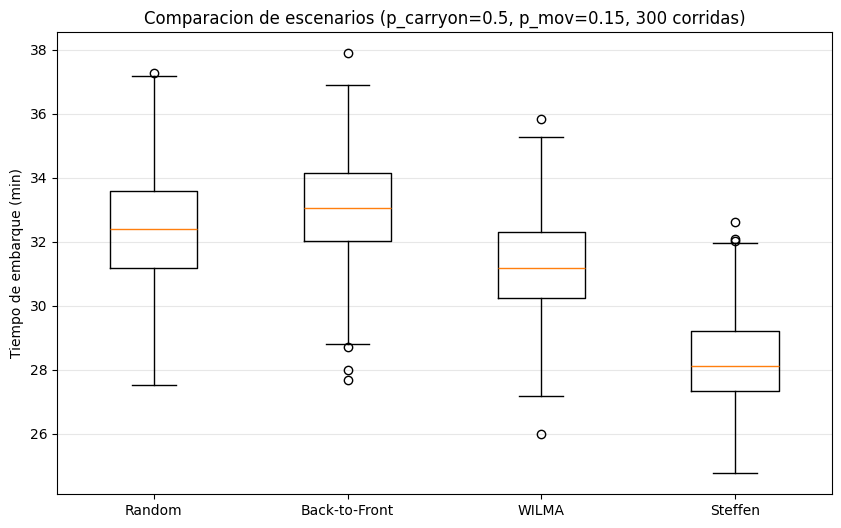

In [15]:
plt.figure(figsize=(10, 6))
plt.boxplot([comparacion[n]["tiempos"] / 60 for n in escenarios],
            tick_labels=list(escenarios.keys()))
plt.ylabel("Tiempo de embarque (min)")
plt.title(f"Comparacion de escenarios (p_carryon={P_CARRYON}, "
          f"p_mov={P_MOV_REDUCIDA}, {N_CORRIDAS} corridas)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 8.d Sensibilidad a la proporción de movilidad reducida
Vemos cómo sube el tiempo medio de embarque a medida que `p_mov` se modifica.

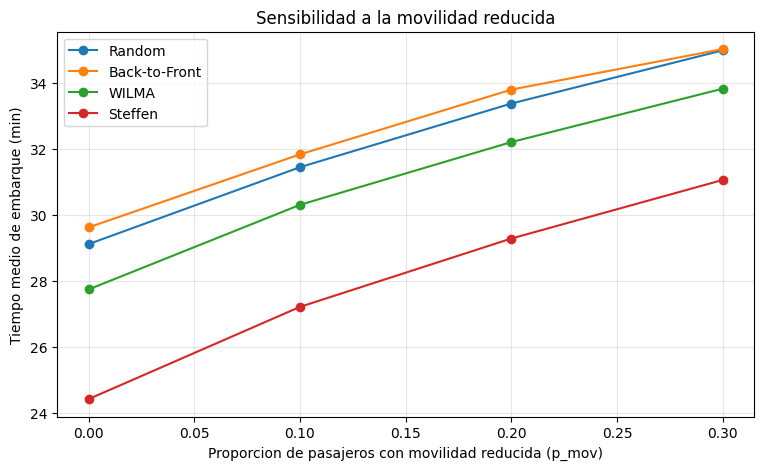

In [16]:
ps_mov = [0.0, 0.1, 0.2, 0.3]
plt.figure(figsize=(9, 5))
for nombre, gen in escenarios.items():
    medias = [correr_montecarlo_bonus(gen, p_mov=pm)["media"] / 60 for pm in ps_mov]
    plt.plot(ps_mov, medias, marker="o", label=nombre)
plt.xlabel("Proporcion de pasajeros con movilidad reducida (p_mov)")
plt.ylabel("Tiempo medio de embarque (min)")
plt.title("Sensibilidad a la movilidad reducida")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 8.e ¿Hay un umbral de familias a partir del cual Steffen deja de ganar?

**Metodología:** en vez de un DIST_TAMANOS fijo, se parametriza `g` = probabilidad de que
una fila sea "familia" (de cualquier tamaño), manteniendo la forma relativa entre tamaños
2/3/4 del DIST_TAMANOS original (0.35 : 0.10 : 0.10). `g=0` es "nadie en familia" (debe
reproducir el resultado sin familias), `g=0.55` es el DIST_TAMANOS actual del bonus, y
`g=1.0` es el extremo "toda fila está ocupada por un grupo familiar".
 
Se corrieron las 4 políticas en 7 valores de `g`, N=300 y `p_mov=0.15` fijo (para aislar el
efecto de las familias del de la movilidad reducida). 

Métrica que utilizamos: la diferencia entre
Steffen y Random en cada punto. Si esa brecha cruza cero, ahí está el umbral. Se eligió
Random y no WILMA porque es la comparación más honesta para la pregunta "¿vale la pena el
esfuerzo de implementar Steffen?". Si ni siquiera le gana a la política más simple posible,
no vale la pena.

In [17]:
def dist_tamanos_g(g):
    """g = prob. de que una fila sea 'familia' de algun tamano (2,3,4), manteniendo
    la forma relativa original (0.35 : 0.10 : 0.10) entre esos tamanos.
    g=0 -> todos solos. g=0.55 -> el DIST_TAMANOS original. g=1.0 -> ninguna fila sola."""
    if g <= 0:
        return {1: 1.0}
    p2 = g * (0.35 / 0.55)
    p3 = g * (0.10 / 0.55)
    p4 = g * (0.10 / 0.55)
    return {1: 1 - g, 2: p2, 3: p3, 4: p4}


politicas_base = {"Random": orden_random, "Back-to-Front": orden_back_to_front,
                   "WILMA": orden_wilma, "Steffen": orden_steffen}
gs = [0.0, 0.2, 0.4, 0.55, 0.7, 0.85, 1.0]

print(f"{'g':<8}" + "".join(f"{p:>16}" for p in politicas_base) + f"{'gap Steffen-Random':>20}")
resultados_g = {}
for g in gs:
    resultados_g[g] = {}
    for nombre, politica in politicas_base.items():
        gen = grupos_con_familias_desde_politica(politica, dist_tamanos_g(g))
        r = correr_montecarlo_bonus(gen, p_mov=0.15)
        resultados_g[g][nombre] = r["media"] / 60
    fila = f"{g:<8}" + "".join(f"{resultados_g[g][p]:>16.2f}" for p in politicas_base)
    fila += f"{resultados_g[g]['Random']-resultados_g[g]['Steffen']:>20.2f}"
    print(fila)

g                 Random   Back-to-Front           WILMA         Steffen  gap Steffen-Random
0.0                32.43           32.90           31.23           28.38                4.04
0.2                32.51           32.93           31.48           28.92                3.59
0.4                32.73           32.86           31.55           29.35                3.37
0.55               32.73           32.97           31.80           29.71                3.02
0.7                32.49           32.88           32.11           30.20                2.29
0.85               32.74           33.06           32.00           30.67                2.07
1.0                32.78           32.93           32.24           30.92                1.86


In [19]:
# Caso extremo real: TODAS las filas son familia de 4 (maxima ruptura posible
# de la alternancia ventana/pasillo de Steffen, en cada fila, siempre).
r_random_extremo = correr_montecarlo_bonus(grupos_con_familias_desde_politica(orden_random, {4: 1.0}), p_mov=0.15)
r_steffen_extremo = correr_montecarlo_bonus(grupos_con_familias_desde_politica(orden_steffen, {4: 1.0}), p_mov=0.15)
print(f"Random (extremo):  {r_random_extremo['media']/60:.2f} min")
print(f"Steffen (extremo): {r_steffen_extremo['media']/60:.2f} min")

Random (extremo):  33.35 min
Steffen (extremo): 32.68 min


**Resultado:** la brecha entre Steffen y Random (la política más simple posible, la que
representa el "no hacer nada") se achica de forma consistente a medida que `g` crece (de
4.04 min en g=0 a 1.86 min en g=1.0), pero **nunca es mayor a cero** dentro de todo el rango que
el modelo puede representar. Incluso en el caso más extremo posible (las 25 filas del avión
son una familia de 4) Steffen (32.68 min) le sigue ganando a Random (33.35 min),
aunque por un margen mucho más chico (0.67 min).

**Conclusión: no existe un umbral de proporción de familias en el que convenga abandonar Steffen por la política más simple posible.** La
recomendación de negocio (Steffen) es robusta.

### 8.g Prioridad de embarque para movilidad reducida: ¿primero, último, o sin prioridad?

**Metodología:** hasta este momento, quién tiene movilidad reducida se sorteaba recién al crear cada
`Pasajero`, después de fijado el orden de embarque y no había forma de darles prioridad.
`asignar_movilidad(asientos, p_mov)` sortea la movilidad reducida **antes**, por asiento;
con eso ya decidido, una política de orden puede partir la cola en "movilidad reducida"
(conservando el orden relativo de cada grupo según la política base) y ponerlos
al principio o al final. `crear_pasajeros_bonus_movilidad_fija` arma los `Pasajero` sin
volver a sortear la movilidad reducida (utiliza la ya decidida).

**Métrica:** tiempo medio de embarque, comparando "sin prioridad" (es decir, las políticas sin modificaciones) contra "movilidad reducida primero" y "último", para las 4 políticas, N=1000,
p_mov=0.15, sin familias (para aislar esta variable de la de 8.c y 8.f).

In [20]:
politicas_base = {"Random": orden_random, "Back-to-Front": orden_back_to_front,
                   "WILMA": orden_wilma, "Steffen": orden_steffen}

def asignar_movilidad(asientos, p_mov):
    """Decide, ANTES de generar el orden, quien tiene movilidad reducida.
    Devuelve un dict {asiento: movilidad_reducida (bool)}, con la misma
    distribucion (independiente, prob p_mov) que el modelo original."""
    return {a: perfil_movilidad(p_mov) for a in asientos}


def crear_pasajeros_bonus_movilidad_fija(grupos, p_carryon, movilidad_por_asiento):
    """Como crear_pasajeros_bonus, pero la movilidad reducida viene ya decidida por asiento
    (no se sortea de nuevo). Reproduce exactamente lo que haria Pasajero.__init__ con esa
    movilidad, sin tocar la clase Pasajero."""
    pasajeros = []
    contador = 0
    for grupo_id, grupo in enumerate(grupos):
        for asiento in grupo:
            contador += 1
            p = Pasajero(asiento=asiento, id=contador, p_carryon=p_carryon, p_mov=0.0)
            mr = movilidad_por_asiento[asiento]
            if mr:
                p.movilidad_reducida = True
                p.velocidad = round(p.velocidad * FACTOR_CAMINAR_MR)
            p.grupo_id = grupo_id
            pasajeros.append(p)
    return pasajeros


def simular_embarque_bonus_movilidad_fija(gen_orden, movilidad_por_asiento, p_carryon=P_CARRYON,
                                          max_segundos=100000):
    orden = gen_orden(asientos)
    grupos = [[a] for a in orden]
    pasajeros = crear_pasajeros_bonus_movilidad_fija(grupos, p_carryon, movilidad_por_asiento)
    avion = Avion(pasajeros)
    if len(pasajeros) != avion.capacidad:
        raise ValueError("Los grupos deben cubrir los 100 asientos una sola vez.")
    avion.ingresar_siguiente_pasajero()
    while not avion.esta_lleno():
        if avion.reloj >= max_segundos:
            raise RuntimeError("El embarque supero el limite de segundos.")
        avion.avanzar_un_segundo()
    return avion


def correr_montecarlo_movilidad_fija(gen_orden, tipo_asignacion="aleatoria", p_mov=0.15,
                                     n_corridas=1000, orden_prioridad=None):
    """tipo_asignacion: 'aleatoria' (como el modelo base), 'pasillo' o 'ventana' (sesgo de
    asiento, ver 8.h). orden_prioridad: None (sin prioridad), 'primero' o 'ultimo'."""
    tiempos = []
    for _ in range(n_corridas):
        if tipo_asignacion == "aleatoria":
            mov = asignar_movilidad(asientos, p_mov)
        else:
            mov = asignar_movilidad_por_tipo_asiento(asientos, p_mov, preferir=tipo_asignacion)

        if orden_prioridad is None:
            def gen_orden_final(asientos_, _gp=gen_orden):
                return _gp(asientos_)
        else:
            def gen_orden_final(asientos_, _gp=gen_orden, _mov=mov, _pr=orden_prioridad):
                base = _gp(asientos_)
                prm = [a for a in base if _mov[a]]
                no_prm = [a for a in base if not _mov[a]]
                return (prm + no_prm) if _pr == "primero" else (no_prm + prm)

        avion = simular_embarque_bonus_movilidad_fija(gen_orden_final, mov)
        tiempos.append(avion.reloj)

    tiempos = np.array(tiempos)
    media = tiempos.mean()
    return {"tiempos": tiempos, "media": media, "desvio": tiempos.std(ddof=1)}


In [ ]:
print(f"{'Politica':<16}{'Sin prioridad':>15}{'Primero':>12}{'Ultimo':>12}{'Mejor opcion':>16}")
baseline_pm = {nombre: comparacion[nombre]["media"] / 60 for nombre in politicas_base}
for nombre, politica in politicas_base.items():
    r_primero = correr_montecarlo_movilidad_fija(politica, orden_prioridad="primero")
    r_ultimo = correr_montecarlo_movilidad_fija(politica, orden_prioridad="ultimo")
    b, pr, ul = baseline_pm[nombre], r_primero["media"]/60, r_ultimo["media"]/60
    mejor = min([("sin prioridad", b), ("primero", pr), ("ultimo", ul)], key=lambda t: t[1])[0]
    print(f"{nombre:<16}{b:>15.2f}{pr:>12.2f}{ul:>12.2f}{mejor:>16}")

Politica          Sin prioridad     Primero      Ultimo    Mejor opcion
Random                    32.46       31.14       32.14         primero
Back-to-Front             33.00       31.07       31.45         primero
WILMA                     31.17       30.28       31.11         primero
Steffen                   28.22       27.64       29.50         primero

Resultado: dar prioridad a los pasajeros con movilidad reducida mejora el tiempo de embarque en las cuatro políticas.

La opción “primero” presenta los menores tiempos en todos los casos:

- Random: 31.14 min vs. 32.46 min sin prioridad.
- Back-to-Front: 31.07 min vs. 33.00 min.
- WILMA: 30.28 min vs. 31.17 min.
- Steffen: 27.64 min vs. 28.22 min.

La opción “último” también mejora respecto de no asignar prioridad en Random, Back-to-Front y WILMA (excepto para el orden Steffen, donde 29.50 min es peor que los 28.22 min sin prioridad), aunque en los casos donde sí mejora presenta tiempos superiores a “primero”.

**Conclusión: establecer prioridad para pasajeros con movilidad reducida y ubicarlos al inicio o al final del embarque reduce muy levenemente el tiempo total en todas las políticas analizadas.**

### 8.h ¿Conviene asignarles asiento de pasillo en vez de ventana?

Hipótesis:

En el motor, solo quien se sienta en la **ventana** puede tener
`hay_bloqueador` (si el asiento intermedio de pasillo ya está ocupado). En ese caso, ese
mismo pasajero paga **tiempo_dejar_pasar()** además de **tiempo_sentado()**. Si esa persona
tiene movilidad reducida, ambos tiempos ya vienen multiplicados por **FACTOR_SENTARSE_MR**.

La hipótesis: sentar a la gente con movilidad reducida en el **pasillo** evita que ocurra 
bloqueo + sentado lento, reduciendo el tiempo de embarque.


Metodología:

**Asignar_movilidad_por_tipo_asiento(asientos, p_mov, preferir=...)** sortea
cuánta gente tiene movilidad reducida (misma distribución que siempre) y la ubica
preferentemente en asientos de pasillo o de ventana (mezclando al azar **dentro** de cada
tipo para no sesgar por fila). N=300, p_mov=0.15, sin familias ni prioridad de orden (para
aislar esta variable).

In [ ]:
def asignar_movilidad_por_tipo_asiento(asientos, p_mov, preferir=None):
    """Igual que asignar_movilidad, pero condicional en 'preferir' ('pasillo' o 'ventana'):
    la movilidad reducida se asigna preferentemente a ese tipo de asiento. El total de
    gente con movilidad reducida sigue siendo ~Binomial(100, p_mov); lo unico que cambia
    es EN QUE ASIENTOS caen. Se mezcla por separado dentro de cada tipo antes de truncar
    -- si no, el truncado queda sesgado hacia las primeras filas (confounder detectado y
    corregido durante el analisis)."""
    n_mr = sum(1 for _ in asientos if random.random() < p_mov)

    if preferir == "pasillo":
        principal = [a for a in asientos if abs(a[1]) == 1]
        secundario = [a for a in asientos if abs(a[1]) == 2]
    elif preferir == "ventana":
        principal = [a for a in asientos if abs(a[1]) == 2]
        secundario = [a for a in asientos if abs(a[1]) == 1]
    else:
        principal = list(asientos)
        secundario = []

    random.shuffle(principal)
    random.shuffle(secundario)
    prioridad = principal + secundario

    asientos_mr = set(prioridad[:n_mr])
    resultado = {}
    for a in asientos:
        resultado[a] = a in asientos_mr
    return resultado


print(f"{'Politica':<16}{'Baseline':>10}{'Pasillo':>10}{'Ventana':>10}{'Mejor opcion':>16}")
for nombre, politica in politicas_base.items():
    r_pasillo = correr_montecarlo_movilidad_fija(politica, tipo_asignacion="pasillo", n_corridas=3000)
    r_ventana = correr_montecarlo_movilidad_fija(politica, tipo_asignacion="ventana", n_corridas=3000)
    b, pa, ve = baseline_pm[nombre], r_pasillo["media"]/60, r_ventana["media"]/60
    mejor = min([("baseline", b), ("pasillo", pa), ("ventana", ve)], key=lambda t: t[1])[0]
    print(f"{nombre:<16}{b:>10.2f}{pa:>10.2f}{ve:>10.2f}{mejor:>16}")

Politica          Baseline   Pasillo   Ventana    Mejor opcion
Random               32.46     32.32     32.67         pasillo
Back-to-Front        33.00     32.80     33.07         pasillo
WILMA                31.17     31.01     30.68         ventana
Steffen              28.22     27.85     27.63         ventana

Resultado: para Steffen, asignar a los pasajeros con movilidad reducida exclusivamente a pasillo (27.85 min) o a ventana (27.63 min) mejora el tiempo respecto del baseline (28.22 min).

Con las 4 políticas completas, la "mejor opción" queda pareja: pasillo gana en Random y Back-to-Front, y ventana gana en WILMA y Steffen. Esto refuerza que estos resultados no permiten afirmar que el pasillo sea mejor que la ventana en general. La mejora parece explicarse principalmente por la concentración de los pasajeros con movilidad reducida en un único tipo de asiento, lo que deja parte de los grupos de embarque sin pasajeros lentos.

Para determinar si el pasillo ofrece una ventaja específica sobre la ventana sería necesario un experimento que permita su presencia en ambos tipos de asiento.
Conclusión: concentrar a los pasajeros con movilidad reducida en un mismo tipo de asiento puede reducir el tiempo de embarque, pero no existe evidencia suficiente para preferir pasillo sobre ventana (el resultado está empatado 2 a 2 entre las 4 políticas).

### 8.i ¿Conviene asignarles los primeros asientos?

Hipótesis:

Además de un aumento en el tiempo de sentado, la característica pricipal de las personas con movilidad reducida es tener una velocidad de caminata mayor. Es por eso que mientras más filas recorren al caminar el pasillo, no solamente retrasan el embarque directamente, sino que indirectamente demoran la caminata de aquellos que vienen detrás. Hipotetizamos que asignarles asientos delanteros reducirá el tiempo de embarque total, ya que caminarán menos por el avión. Asimismo, realizaremos una simulación donde los pasajeros de movilidad reducida irán al final del avión, para demostrar que efectivamente el tiempo de embarque aumenta. 


Metodología:

**Asignar_movilidad_por_tipo_asiento(asientos, p_mov, preferir=...)** sortea cuánta gente tiene movilidad reducida y la ubica preferentemente en las primeras o últimas filas del avión. Dentro de cada fila, los asientos se mezclan al azar para no sesgar la asignación hacia un asiento específico. Se compara la asignación a las primeras filas con la asignación a las últimas filas, manteniendo constantes el resto de las condiciones del modelo. `N=2000`, `p_mov=0.15`, sin familias ni prioridad de orden, para aislar el efecto de la distancia que deben recorrer los pasajeros con movilidad reducida sobre el tiempo total de embarque.

In [ ]:

def asignar_movilidad_por_tipo_asiento(asientos, p_mov, preferir=None):
    # Cantidad de personas con movilidad reducida
    # Sigue una Binomial(100, p_mov), igual que en los experimentos anteriores.
    n_mr = sum(1 for _ in asientos if random.random() < p_mov)


    # Construimos el orden de prioridad

    if preferir == "pasillo":
        principal = [a for a in asientos if abs(a[1]) == 1]
        secundario = [a for a in asientos if abs(a[1]) == 2]

        random.shuffle(principal)
        random.shuffle(secundario)

        prioridad = principal + secundario

    elif preferir == "ventana":

        principal = [a for a in asientos if abs(a[1]) == 2]
        secundario = [a for a in asientos if abs(a[1]) == 1]

        random.shuffle(principal)
        random.shuffle(secundario)

        prioridad = principal + secundario

    elif preferir in ("primeros", "ultimos"):
        # Las filas están dadas por a[0]
        filas = sorted(set(a[0] for a in asientos))

        if preferir == "primeros":
            filas = filas
        else:
            filas = list(reversed(filas))

        prioridad = []
        # Dentro de cada fila mezclamos aleatoriamente
        # para no favorecer siempre al mismo asiento.
        for fila in filas:
            asientos_fila = [a for a in asientos if a[0] == fila]
            random.shuffle(asientos_fila)
            prioridad.extend(asientos_fila)

    else:

        prioridad = list(asientos)
        random.shuffle(prioridad)


    # Selección final de pasajeros con movilidad reducida

    asientos_mr = set(prioridad[:n_mr])
    resultado = {}

    for a in asientos:
        resultado[a] = a in asientos_mr

    return resultado


# Ejecutamos Monte Carlo

resultados_primeros = {}
resultados_ultimos = {}

for nombre, politica in politicas_base.items():
    resultados_primeros[nombre] = correr_montecarlo_movilidad_fija(politica,tipo_asignacion="primeros",n_corridas=2000)
    resultados_ultimos[nombre] = correr_montecarlo_movilidad_fija(politica, tipo_asignacion="ultimos", n_corridas=2000)


# Tabla de resultados

print(f"{'Politica':<16}" f"{'Baseline':>12}" f"{'Primeros':>12}" f"{'Ultimos':>12}" f"{'Diferencia':>14}")

for nombre in politicas_base:
    baseline = baseline_pm[nombre]
    primeros = resultados_primeros[nombre]["media"] / 60
    ultimos = resultados_ultimos[nombre]["media"] / 60
    diferencia = ultimos - primeros
    
    print(f"{nombre:<16}" f"{baseline:>12.2f}" f"{primeros:>12.2f}" f"{ultimos:>12.2f}" f"{diferencia:>14.2f}")

Politica            Baseline    Primeros     Ultimos    Diferencia
Random                 32.46       30.52       32.96          2.44
Back-to-Front          33.00       30.93       32.87          1.94
WILMA                  31.17       29.02       32.06          3.04
Steffen                28.22       25.51       31.21          5.70

## 9. Conclusiones y extensiones

### Resultados principales

Los resultados corresponden a $N = 300$ corridas por punto y se basan en las simulaciones presentadas en las secciones anteriores.

**1. Movilidad reducida.** La presencia de pasajeros con movilidad reducida **aumenta el tiempo de embarque en las cuatro políticas** analizadas. El incremento se ubica entre $11\%$ y $16\%$ según la política. Además, el tiempo medio crece aproximadamente de forma **lineal** con `p_mov`: para la política más lenta pasa de $\approx 29$ minutos con `p_mov = 0` a $\approx 35$ minutos con `p_mov = 0,3`.

**2. Comportamiento de Steffen.** Steffen presenta el **menor tiempo de embarque** en los escenarios analizados: $24{,}5$ minutos sin movilidad reducida y $28{,}4$ minutos con `p_mov = 0,15`. Sin embargo, también presenta el **mayor aumento relativo** ante la incorporación de esta heterogeneidad, con un incremento de $16\%$.

Este resultado debe interpretarse considerando las diferencias entre el modelo teórico y una aplicación práctica. La simulación supone que los pasajeros respetan exactamente el orden establecido; en una situación real aparecen restricciones adicionales. En el modelo, **Steffen es la política más afectada por la incorporación de familias**: con familias su ventaja disminuye porque se altera la estructura de alternancia entre ventana y pasillo (ver punto 3). La prioridad de embarque para pasajeros con movilidad reducida, en cambio, no perjudica a Steffen (ver punto 5).

La literatura citada en el trabajo señala además **dificultades para implementar Steffen en la práctica**, debido a la necesidad de asignar a cada pasajero una posición específica en la cola y a la dificultad de adaptar este esquema al embarque de grupos o familias.

> **Fuente:** [Scientific American, *There Are Quicker Ways to Board a Plane — So Why Don't Airlines Use Them?*](https://www.scientificamerican.com/article/there-are-quicker-ways-to-board-a-plane-so-why-dont-airlines-use-them/)

**3. Embarque de familias.** Cuando las familias embarcan juntas, la comparación adecuada es entre las **cuatro políticas adaptadas para respetar grupos familiares**. No corresponde compararlas con la política *Familias* del modelo inicial, ya que esta utilizaba un orden aleatorio y mezclaba distintos efectos. Con esta comparación, **Steffen continúa presentando el menor tiempo de embarque**, con $29{,}70$ minutos, aunque su ventaja se reduce: la diferencia promedio pasa de $3{,}99$ minutos ($14\%$) sin familias a $2{,}82$ minutos ($9\%$) con familias. Steffen presenta además el **mayor aumento absoluto**, de $1{,}48$ minutos. Esto se debe a que las familias dificultan la alternancia entre ventana y pasillo utilizada por esta política.

**4. Proporción de familias.** **No se observa un nivel de presencia de familias que permita que Random supere a Steffen.** Al variar la proporción de filas ocupadas por familias entre $0\%$ y $100\%$ (incluyendo el caso extremo en que todas las filas corresponden a familias de cuatro personas) Steffen mantiene un menor tiempo de embarque. La diferencia se reduce a medida que aumenta la proporción de familias: pasa de $4{,}04$ minutos con $0\%$ de familias a $0{,}67$ minutos con $100\%$. Dentro de los supuestos del modelo, **la ventaja de Steffen se mantiene incluso en escenarios con alta presencia de familias**.

**5. Prioridad para movilidad reducida.** Dar prioridad de embarque a los pasajeros con movilidad reducida (ubicarlos al principio de la cola) **reduce levemente el tiempo de embarque en las cuatro políticas** (sección 8.g). La mejora es mayor en Back-to-Front ($\approx 1{,}9$ minutos) y Random ($\approx 1{,}3$ minutos), y algo menor en WILMA ($\approx 0{,}9$ minutos) y Steffen ($\approx 0{,}8$ minutos). La opción "último" también mejora respecto de no asignar prioridad en Random, Back-to-Front y WILMA, pero no en Steffen, donde sube a $29{,}50$ minutos (peor que los $28{,}40$ minutos sin prioridad). La mejora con "primero" ocurre porque sacar a los pasajeros más lentos de la mitad de la cola evita que generen cuellos de botella para quienes vienen detrás. Sin embargo, la ganancia de tiempo no es demasiado grande, por lo que esta política no es la recomendada para amortiguar este problema. 
